In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Nassau Candy Distributor.csv")

In [4]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
8025,8026,US-2024-148362-CHO-SCR-58000,01-07-2025,29-12-2029,Standard Class,148362,United States,Indianapolis,Indiana,46203,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,3.6,1,2.5,1.1
2418,2419,US-2022-115742-CHO-FUD-51000,18-04-2024,13-10-2027,Standard Class,115742,United States,New Albany,Indiana,47150,Chocolate,Interior,CHO-FUD-51000,Wonka Bar - Fudge Mallows,21.6,6,14.4,7.2
8860,8861,US-2024-142391-CHO-TRI-54000,24-09-2025,17-03-2030,Same Day,142391,United States,Seattle,Washington,98115,Chocolate,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,37.5,10,24.5,13.0
6899,6900,US-2024-161809-CHO-FUD-51000,20-01-2025,18-07-2029,Standard Class,161809,United States,Los Angeles,California,90045,Chocolate,Pacific,CHO-FUD-51000,Wonka Bar - Fudge Mallows,10.8,3,7.2,3.6
6755,6756,US-2023-109827-CHO-SCR-58000,25-12-2025,23-06-2029,Standard Class,109827,United States,Phoenix,Arizona,85023,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,3.6,1,2.5,1.1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [5]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [6]:
# checking null values
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [8]:
# checking duplicates
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
10189    False
10190    False
10191    False
10192    False
10193    False
Length: 10194, dtype: bool

In [9]:
# Removing Invalid Rows
df = df[df['Sales'] > 0]
df = df[df['Cost'] > 0]

In [11]:
# adding column gross profit
df['Gross Profit'] = df['Sales'] - df['Cost']

In [12]:
# important metrics
df['Gross Margin'] = df['Gross Profit'] / df['Sales']
df['Profit per Unit'] = df['Gross Profit'] / df['Units']

In [13]:
# top products by profit
top_profit = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)
print(top_profit.head(5))

Product Name
Wonka Bar -Scrumdiddlyumptious       19357.50
Wonka Bar - Triple Dazzle Caramel    18610.20
Wonka Bar - Milk Chocolate           17443.37
Wonka Bar - Nutty Crunch Surprise    16819.95
Wonka Bar - Fudge Mallows            16593.60
Name: Gross Profit, dtype: float64


In [14]:
# top products by margin
top_margin = df.groupby('Product Name')['Gross Margin'].mean().sort_values(ascending=False)
print(top_margin.head(5))

Product Name
Everlasting Gobstopper               0.800000
Hair Toffee                          0.777778
Wonka Bar - Nutty Crunch Surprise    0.713467
Wonka Bar -Scrumdiddlyumptious       0.694444
Wonka Bar - Fudge Mallows            0.666667
Name: Gross Margin, dtype: float64


In [15]:
# categorize products
def category(row):
    if row['Sales'] > df['Sales'].median() and row['Gross Margin'] > df['Gross Margin'].median():
        return "High Sales High Margin"
    elif row['Sales'] > df['Sales'].median():
        return "High Sales Low Margin"
    elif row['Gross Margin'] > df['Gross Margin'].median():
        return "Low Sales High Margin"
    else:
        return "Low Sales Low Margin"

df['Category'] = df.apply(category, axis=1)

In [16]:
# division analysis
division = df.groupby('Division').agg({
    'Sales': 'sum',
    'Gross Profit': 'sum',
    'Gross Margin': 'mean'
})

print(division)

               Sales  Gross Profit  Gross Margin
Division                                        
Chocolate  131692.90      88824.62      0.674582
Other        9663.25       4333.45      0.376725
Sugar         427.48        284.73      0.576890


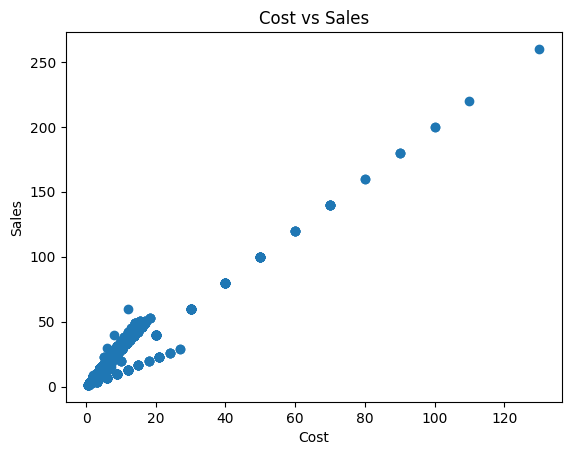

In [17]:
# cost vs sales analysis
import matplotlib.pyplot as plt

plt.scatter(df['Cost'], df['Sales'])
plt.xlabel("Cost")
plt.ylabel("Sales")
plt.title("Cost vs Sales")
plt.show()

In [18]:
profit = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)

cum_profit = profit.cumsum()
cum_percent = cum_profit / profit.sum()

print(cum_percent.head(20))

Product Name
Wonka Bar -Scrumdiddlyumptious       0.207159
Wonka Bar - Triple Dazzle Caramel    0.406320
Wonka Bar - Milk Chocolate           0.592995
Wonka Bar - Nutty Crunch Surprise    0.772997
Wonka Bar - Fudge Mallows            0.950577
Lickable Wallpaper                   0.992635
Wonka Gum                            0.995960
Everlasting Gobstopper               0.997073
Kazookles                            0.998066
Hair Toffee                          0.998703
Fizzy Lifting Drinks                 0.999208
Laffy Taffy                          0.999567
SweeTARTS                            0.999874
Nerds                                0.999949
Fun Dip                              1.000000
Name: Gross Profit, dtype: float64


In [5]:
# factories data
factories_data = [
    {"Factory": "Lot's O' Nuts", "Latitude": 32.881893, "Longitude": -111.768036, "Product Name": "Wonka Bar - Nutty Crunch Surprise"},
    {"Factory": "Lot's O' Nuts", "Latitude": 32.881893, "Longitude": -111.768036, "Product Name": "Wonka Bar - Fudge Mallows"},
    {"Factory": "Lot's O' Nuts", "Latitude": 32.881893, "Longitude": -111.768036, "Product Name": "Wonka Bar -Scrumdiddlyumptious"},
    {"Factory": "Wicked Choccy's", "Latitude": 32.076176, "Longitude": -81.088371, "Product Name": "Wonka Bar - Milk Chocolate"},
    {"Factory": "Wicked Choccy's", "Latitude": 32.076176, "Longitude": -81.088371, "Product Name": "Wonka Bar - Triple Dazzle Caramel"},
    {"Factory": "Sugar Shack", "Latitude": 48.11914, "Longitude": -96.18115, "Product Name": "Laffy Taffy"},
    {"Factory": "Sugar Shack", "Latitude": 48.11914, "Longitude": -96.18115, "Product Name": "SweeTARTS"},
    {"Factory": "Sugar Shack", "Latitude": 48.11914, "Longitude": -96.18115, "Product Name": "Nerds"},
    {"Factory": "Sugar Shack", "Latitude": 48.11914, "Longitude": -96.18115, "Product Name": "Fun Dip"},
    {"Factory": "Sugar Shack", "Latitude": 48.11914, "Longitude": -96.18115, "Product Name": "Fizzy Lifting Drinks"},
    {"Factory": "Secret Factory", "Latitude": 41.446333, "Longitude": -90.565487, "Product Name": "Everlasting Gobstopper"},
    {"Factory": "Secret Factory", "Latitude": 41.446333, "Longitude": -90.565487, "Product Name": "Lickable Wallpaper"},
    {"Factory": "Secret Factory", "Latitude": 41.446333, "Longitude": -90.565487, "Product Name": "Wonka Gum"},
    {"Factory": "The Other Factory", "Latitude": 35.1175, "Longitude": -89.971107, "Product Name": "Hair Toffee"},
    {"Factory": "The Other Factory", "Latitude": 35.1175, "Longitude": -89.971107, "Product Name": "Kazookles"}
]
factories_df = pd.DataFrame(factories_data)
df = pd.merge(df, factories_df, on='Product Name', how='left')

In [6]:
# handeling date
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y', errors='coerce')
df['Delivery Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# Data scrub
initial_rows = len(df)
df = df[df['Sales'] > 0]
df = df[df['Cost'] > 0]
df = df.dropna(subset=['Order Date', 'Ship Date'])
print(f"Removed {initial_rows - len(df)} invalid/corrupt rows.")

Removed 0 invalid/corrupt rows.


In [7]:
# financial kpi genration
df['Gross Profit'] = df['Sales'] - df['Cost']
df['Gross Margin'] = df['Gross Profit'] / df['Sales']
df['Profit per Unit'] = df['Gross Profit'] / df['Units']

# Extra KPIs requested
total_sales = df['Sales'].sum()
total_profit = df['Gross Profit'].sum()
df['Revenue Contribution %'] = df['Sales'] / total_sales
df['Profit Contribution %'] = df['Gross Profit'] / total_profit
df[['Sales', 'Gross Profit', 'Delivery Lead Time', 'Gross Margin']].describe()

,Sales,Gross Profit,Delivery Lead Time,Gross Margin
count,10194.000000,10194.000000,10194.000000,10194.000000
mean,13.908537,9.166451,1320.841868,0.665140
std,11.341020,6.643740,262.444892,0.067210
min,1.250000,0.250000,904.000000,0.076923
25%,7.200000,4.900000,1271.000000,0.653333
50%,10.800000,7.470000,1274.000000,0.666667
75%,18.000000,12.250000,1638.000000,0.694444
max,260.000000,130.000000,1642.000000,0.800000


In [8]:
df['Order Month'] = df['Order Date'].dt.to_period('M')
monthly_margins = df.groupby(['Product Name', 'Order Month'])['Gross Margin'].mean().reset_index()
margin_volatility = monthly_margins.groupby('Product Name')['Gross Margin'].std().fillna(0).sort_values(ascending=False)
print("Highest Margin Volatility (Standard Deviation of monthly margins):\n")
print(margin_volatility.head())

Highest Margin Volatility (Standard Deviation of monthly margins):

Product Name
Wonka Bar - Triple Dazzle Caramel    8.346761e-17
Wonka Bar - Fudge Mallows            5.176442e-17
Wonka Bar -Scrumdiddlyumptious       4.009654e-17
SweeTARTS                            3.634058e-17
Wonka Bar - Milk Chocolate           3.273869e-17
Name: Gross Margin, dtype: float64


Top 5 Most Congestion-Prone States (Longest Average Delays):

                Avg_Lead_Time  Total_Orders
State/Province                             
West Virginia     1638.000000             4
North Dakota      1637.857143             7
Saskatchewan      1457.000000             2
Manitoba          1455.333333            12
Iowa              1443.900000            30


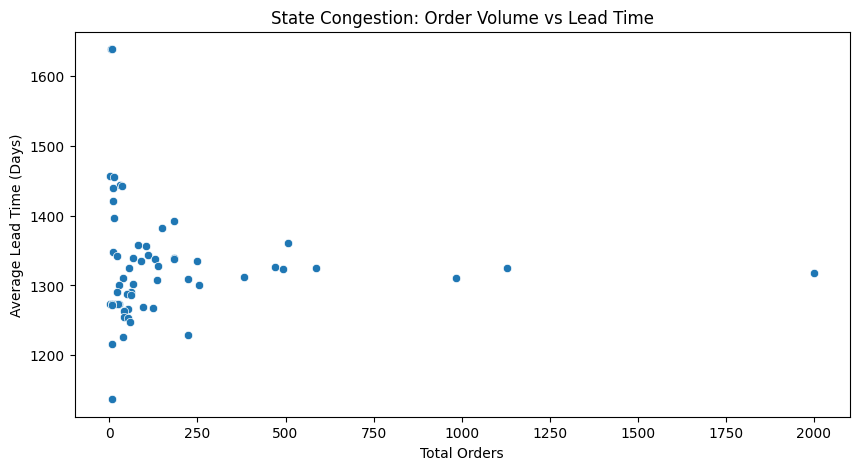

In [9]:
state_logistics = df.groupby('State/Province').agg(
    Avg_Lead_Time=('Delivery Lead Time', 'mean'),
    Total_Orders=('Row ID', 'count')
).sort_values(by='Avg_Lead_Time', ascending=False)
print("Top 5 Most Congestion-Prone States (Longest Average Delays):\n")
print(state_logistics.head(5))

plt.figure(figsize=(10, 5))
sns.scatterplot(data=state_logistics, x='Total_Orders', y='Avg_Lead_Time')
plt.title("State Congestion: Order Volume vs Lead Time")
plt.xlabel('Total Orders')
plt.ylabel('Average Lead Time (Days)')
plt.show()

In [10]:
profit = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)
cum_profit = profit.cumsum() / profit.sum()
# Revenue Pareto
revenue = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
cum_revenue = revenue.cumsum() / revenue.sum()

print("Profit Dependency (Products satisfying >80%):", len(cum_profit[cum_profit <= 0.8]) + 1)
print("Revenue Dependency (Products satisfying >80%):", len(cum_revenue[cum_revenue <= 0.8]) + 1)

Profit Dependency (Products satisfying >80%): 5
Revenue Dependency (Products satisfying >80%): 5


In [11]:
factory_risk = df.groupby('Factory').agg(
    Profit_Contribution=('Gross Profit', 'sum')
)
factory_risk['Risk %'] = factory_risk['Profit_Contribution'] / factory_risk['Profit_Contribution'].sum()
print("Profit generated per factory:\n")
print(factory_risk.sort_values(by='Risk %', ascending=False))

Profit generated per factory:

                   Profit_Contribution    Risk %
Factory                                         
Lot's O' Nuts                 52771.05  0.564742
Wicked Choccy's               36053.57  0.385836
Secret Factory                 4344.70  0.046496
The Other Factory               152.25  0.001629
Sugar Shack                     121.23  0.001297
